# 10 — Integrated dashboard and research conclusions
**Purpose:** assemble all completed phases into an evidence-linked dashboard, analytical timeline, output inventory, and cautious research-question conclusions.  
**Inputs:** generated tables, charts, maps, event metadata, and QA outputs from notebooks 01–09 and 11.  
**Outputs:** integrated timeline, output inventory, seven-question summary, conclusions Markdown, and portable HTML dashboard.  
**Runtime:** typically under two minutes; no Earth Engine request is required.  
**Dependencies:** completed analysis and V2 QA notebooks, plus packages in `requirements.txt`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.7 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import HTML, display
from src.config import SETTINGS
from src.reporting import (
    build_output_inventory, build_research_question_summary,
    build_static_dashboard, plot_integrated_event_timeline,
    read_json_if_present, write_research_conclusions,
)
from src.trend_analysis import load_integrated_features
from src.utils import ensure_output_directories
ensure_output_directories()


## Load the most complete feature table
The anomaly-augmented table is preferred. If Phase 8 could not produce it, the base Phase 6 feature store is used and anomaly-dependent conclusions are marked unavailable rather than fabricated.

In [3]:
augmented_path = (
    SETTINGS.output_tables / 'langtang_monthly_features_with_anomaly.csv'
)
feature_path = (
    augmented_path if augmented_path.exists()
    else SETTINGS.output_tables / 'langtang_monthly_features.csv'
)
features = load_integrated_features(feature_path)
event_metadata = read_json_if_present(
    SETTINGS.output_tables / 'event_windows.json'
)
print('Feature source:', feature_path)
print('Feature period:', features['date'].min(), 'to', features['date'].max())
print('Event metadata available:', bool(event_metadata))


Feature source: /content/drive/MyDrive/langtang-glacier-ai/outputs/tables/langtang_monthly_features_with_anomaly.csv
Feature period: 2015-07-01 00:00:00 to 2026-08-01 00:00:00
Event metadata available: True


## Integrated analytical timeline
The aligned panels combine regional climate, snow proxy, and anomaly information. Shading marks the 12 months before the documented event when event metadata exist. Temporal alignment shows association only; it does not establish a causal chain.

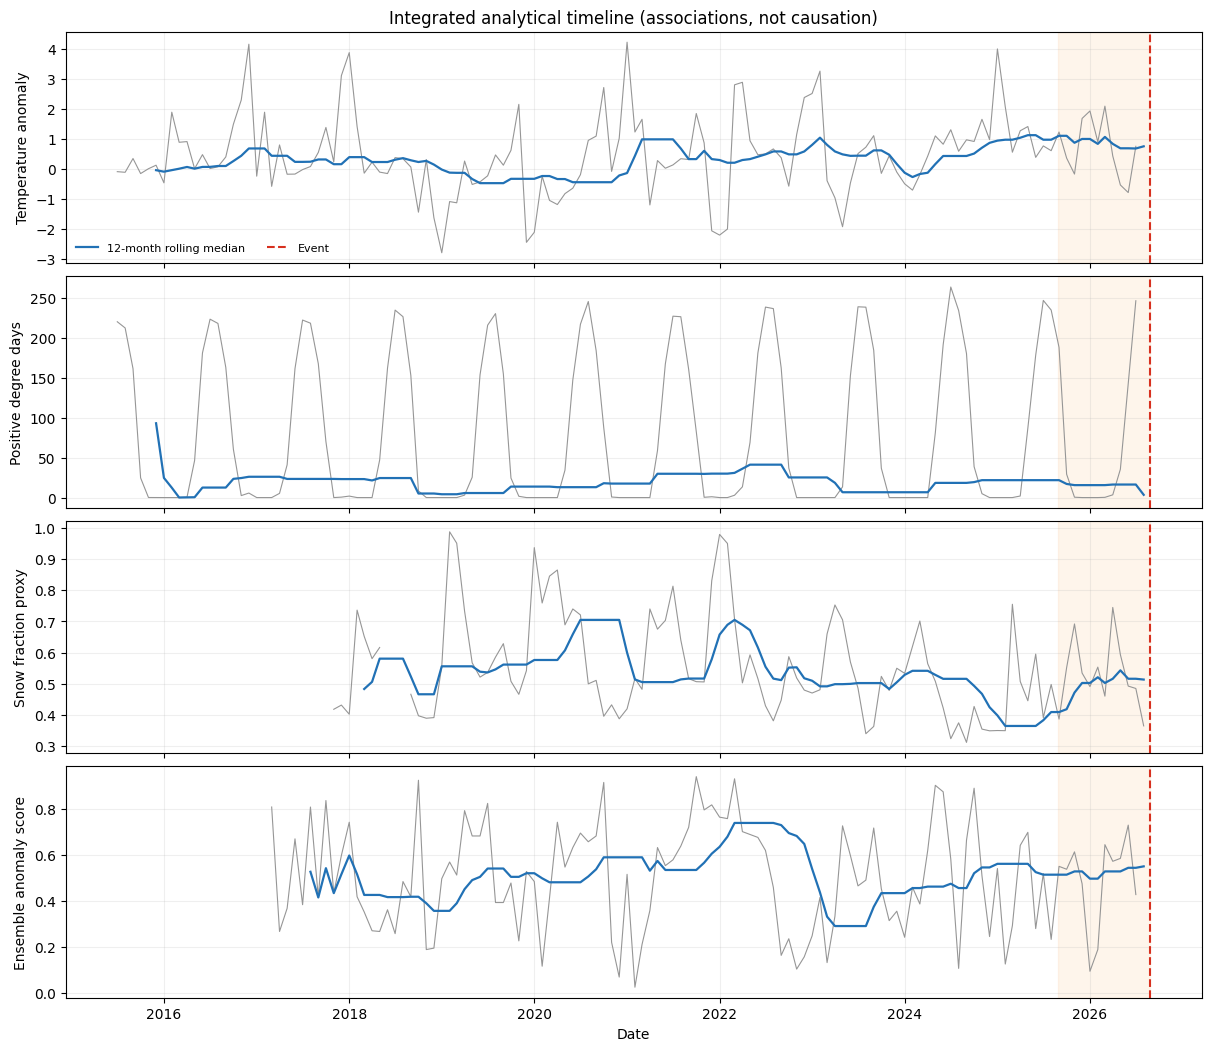

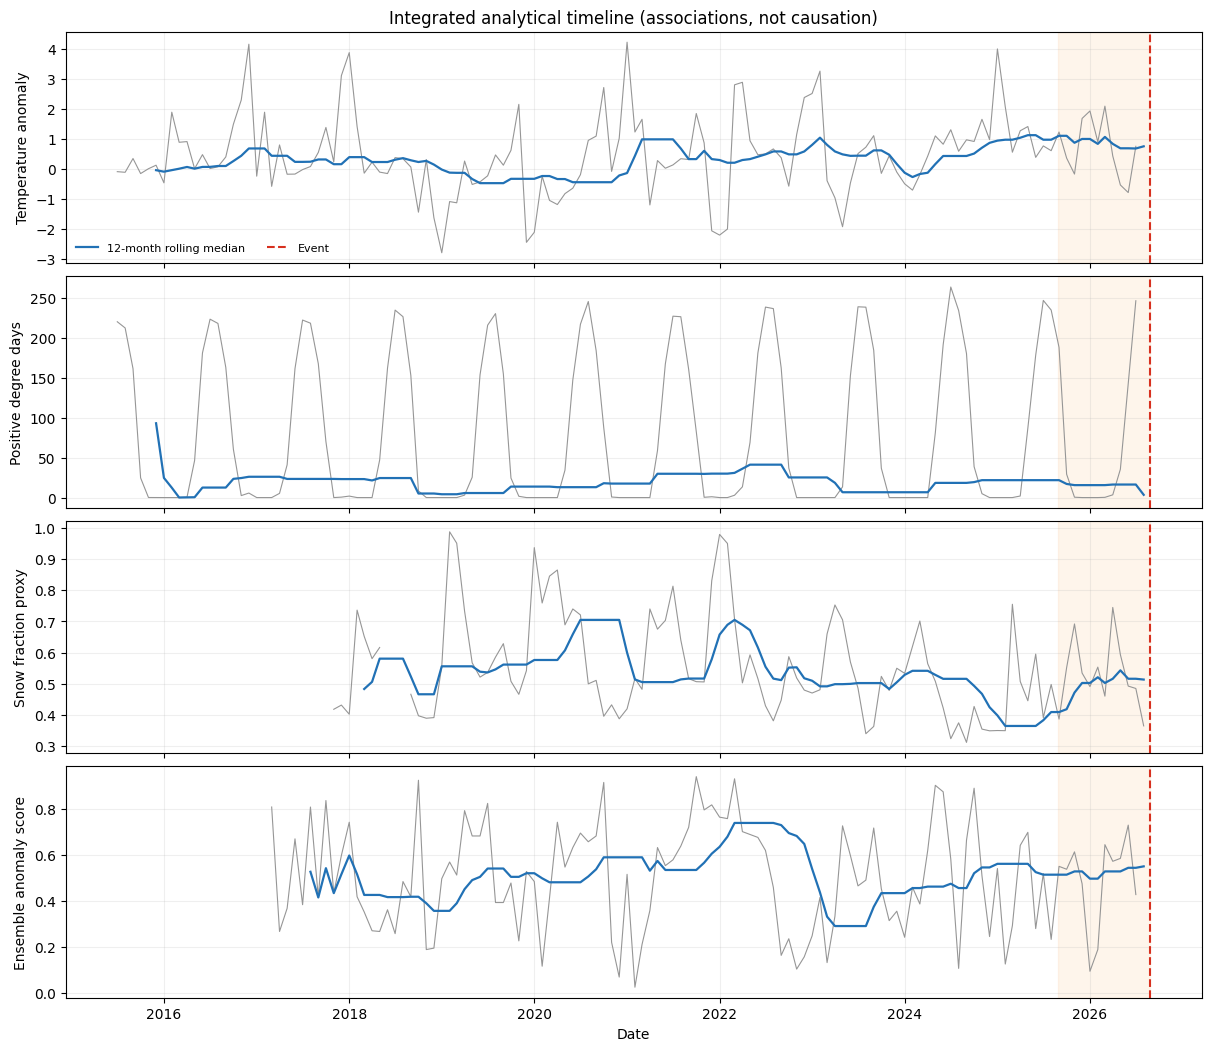

In [4]:
timeline_figure = plot_integrated_event_timeline(
    features, event_metadata,
    SETTINGS.output_charts / 'integrated_event_timeline.png',
)
display(timeline_figure)


## Evidence-linked research-question summary
The summary uses only files that exist. Numerical statements are generated from saved tables, retain missing-data states, and explicitly separate exploratory detection from prediction or causation.

In [5]:
output_root = SETTINGS.output_tables.parent
inventory = build_output_inventory(output_root)
summary = build_research_question_summary(
    output_root, features, event_metadata
)
inventory.to_csv(
    SETTINGS.output_tables / 'research_output_inventory.csv', index=False
)
summary.to_csv(
    SETTINGS.output_tables / 'research_question_summary.csv', index=False
)
display(summary)
display(inventory)


,research_question,topic,evidence_grade,evidence_type,evidence_summary,source_outputs
0,RQ1,Long-term environmental change,EXPLORATORY,STATISTICAL ASSOCIATION,Trend diagnostics are available for 7 features...,trend_summary.csv
1,RQ2,"Climate, snow, and melt trends",EXPLORATORY,STATISTICAL ASSOCIATION,6 exploratory Mann–Kendall results are flagged...,trend_summary.csv
2,RQ3,Pre-event seasonal anomalies,EXPLORATORY,OBSERVATION AND STATISTICAL ASSOCIATION,0 of 11 scored pre-event months exceeded the c...,anomaly_scores.csv
3,RQ4,Satellite-observed event-associated change,DATA INSUFFICIENT,OBSERVATION,"Sentinel-2 observations exist, but quantitativ...",Sentinel-2/Sentinel-1 event outputs
4,RQ5,Variables contributing to anomaly scores,EXPLORATORY,STATISTICAL ASSOCIATION,The most frequent largest standardized contrib...,anomaly_scores.csv; pca_loadings.csv
5,RQ6,Detectable precursory combination,UNSUPPORTED,HYPOTHESIS,The unsupervised results can identify unusual ...,Integrated exploratory outputs
6,RQ7,What cannot be concluded,STRONG,UNSUPPORTED CAUSAL INTERPRETATION,The workflow cannot establish collapse causati...,docs/limitations.md


,kind,product,relative_path,status,size_bytes
0,qa,Feature provenance,qa/feature_provenance.csv,pending,<NA>
1,qa,Matched August climate,qa/climate_matched_august_1_24.csv,pending,<NA>
2,qa,Antecedent climate windows,qa/climate_event_antecedent_windows.csv,pending,<NA>
3,qa,Sentinel-1 candidate tracks,qa/sentinel1_candidate_track_qa.csv,available,1005
4,qa,Sentinel-1 angle sensitivity,qa/sentinel1_angle_mask_sensitivity.csv,pending,<NA>
5,qa,Sentinel-2 proxy sensitivity,qa/sentinel2_proxy_trend_sensitivity.csv,pending,<NA>
6,qa,ROI provenance,qa/roi_provenance.json,available,554
7,table,Optical candidate changes,tables/candidate_spectral_change_polygons.geojson,pending,<NA>
8,table,Monthly feature store,tables/langtang_monthly_features.csv,available,107338
9,table,Feature store with anomaly scores,tables/langtang_monthly_features_with_anomaly.csv,available,177455


## Conclusions and portable dashboard
The HTML file uses relative links to existing charts, maps, and tables in `outputs/`. Keep that directory structure together when sharing it. Pending products remain visibly marked pending.

In [6]:
conclusions_path = output_root / 'research_conclusions.md'
v2_conclusions_path = output_root / 'v2_research_conclusions.md'
write_research_conclusions(summary, inventory, conclusions_path)
write_research_conclusions(summary, inventory, v2_conclusions_path)
dashboard_path = build_static_dashboard(
    output_root, inventory, summary, event_metadata
)
print('Saved:', conclusions_path)
print('Saved:', v2_conclusions_path)
print('Saved:', dashboard_path)
display(HTML(dashboard_path.read_text()))


Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/research_conclusions.md
Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/v2_research_conclusions.md
Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/research_dashboard.html


## Final scientific checkpoint
Read `docs/limitations.md` before using any conclusion. This project does not provide a collapse classifier, warning system, causal attribution, calibrated probability, InSAR displacement, validated debris boundary, or event-volume estimate. A single event cannot establish predictive skill. Pending post-event Sentinel-1 availability should remain pending until a comparable same-track acquisition exists; do not substitute a mismatched orbit merely to complete the dashboard.